In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score,
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [154]:
datos = pd.read_csv("datos_train.csv")

In [155]:
datos["estrato_social"] = datos["estrato_social"].astype(str)

In [156]:
datos["target"] = (datos["categoria"] == "TECNOLOGIA").astype(int)
datos.drop(columns="categoria", inplace=True)

In [157]:
datos["target"].value_counts()

target
0    19740
1      433
Name: count, dtype: int64

In [158]:
datos

,id_cliente,fecha,id_aliado,tipo_transaccion,id_transaccion,puntos,valor_transaccion,genero,fecha_nacimiento,estrato_social,estado_civil,ocupacion,ciudad,saldo_puntos,target
0,46601900,2021-02-22,21,Sale,15839805329,36.0,25410.00,M,1968-03-19,2.0,Casado,Independiente,BOGOTA,37042,0
1,46601900,2021-02-22,21,Sale,15839805329,28.0,20288.00,M,1968-03-19,2.0,Casado,Independiente,BOGOTA,37042,0
2,46601900,2021-02-22,21,Sale,15839805329,27.0,19194.00,M,1968-03-19,2.0,Casado,Independiente,BOGOTA,37042,0
3,46601900,2021-02-22,21,Sale,15839805329,29.0,20511.00,M,1968-03-19,2.0,Casado,Independiente,BOGOTA,37042,0
4,46601900,2021-02-22,21,Sale,15839805329,26.0,18344.00,M,1968-03-19,2.0,Casado,Independiente,BOGOTA,37042,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20168,1118030411,2022-03-07,21,Sale,16154969307,36.0,25700.00,F,NaN,3.0,Divorciado,Independiente,BOGOTA,807,0
20169,46601900,2022-05-18,20,Sale,16220935028,61.0,33650.00,M,1968-03-19,2.0,Casado,Independiente,BOGOTA,37042,0
20170,367538200,2021-12-30,20,Sale,16098271353,111.0,122818.78,F,1957-01-08,6.0,Casado,Empleado,BOGOTA,1663,0
20171,204277850,2022-01-15,21,Sale,16109198909,16.0,11600.00,F,1978-08-11,2.0,Casado,Empleado,BOGOTA,549,0


In [159]:
datos = datos[
    [
        "tipo_transaccion",
        "valor_transaccion",
        "id_aliado",
        "genero",
        "estrato_social",
        "estado_civil",
        "ocupacion",
        "ciudad",
        "target",
    ]
]

In [160]:
X = datos.drop(columns=["target"])  # variables predictoras
y = datos["target"]

In [161]:
num_vars = ["valor_transaccion"]
cat_vars = [
    "tipo_transaccion",
    "id_aliado",
    "genero",
    "estrato_social",
    "estado_civil",
    "ocupacion",
    "ciudad",
]

In [162]:
# Escalar numéricas
scaler = StandardScaler()
X_num = scaler.fit_transform(X[num_vars])

# Codificar categóricas
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_cat = ohe.fit_transform(X[cat_vars])

# Concatenar
X_transformed = np.hstack([X_num, X_cat])

In [163]:
# Dividir en entrenamiento y validación
X_train, X_test, y_train, y_test = train_test_split(
    X_transformed, y, test_size=0.2, random_state=42, stratify=y
)

In [164]:
# --- Modelo base ---
log_reg = LogisticRegression(class_weight="balanced", max_iter=1000, solver="liblinear")

In [165]:
# --- GridSearch ---
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["liblinear", "saga"],
    "class_weight": [None, "balanced"],
}

grid = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    scoring="roc_auc",  # puedes usar "roc_auc" o "recall" también
    cv=5,
    n_jobs=-1,
)

In [166]:
grid.fit(X_train, y_train)
print("Mejores parámetros:", grid.best_params_)

Mejores parámetros: {'C': 10, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}


In [167]:
# Entrenar modelo final con mejores parámetros

best_model = LogisticRegression(**grid.best_params_, max_iter=1000, random_state=42)
best_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,10
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [168]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

In [169]:
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))

ROC AUC: 0.8223354761322479

Matriz de confusión:
 [[2749 1199]
 [  15   72]]

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.99      0.70      0.82      3948
           1       0.06      0.83      0.11        87

    accuracy                           0.70      4035
   macro avg       0.53      0.76      0.46      4035
weighted avg       0.97      0.70      0.80      4035



In [171]:
from sklearn.ensemble import RandomForestClassifier

In [172]:
# Definir el modelo base con class_weight para manejar el desbalance
rf = RandomForestClassifier(class_weight="balanced", random_state=42)

In [173]:
# Definir el grid de hiperparámetros
param_grid = {
    "n_estimators": [100, 200, 300],  # número de árboles
    "max_depth": [None, 5, 10, 20],  # profundidad máxima
    "min_samples_split": [2, 5, 10],  # mínimo de muestras para dividir
    "min_samples_leaf": [1, 2, 4],  # mínimo de muestras por hoja
    "max_features": ["sqrt", "log2"],  # cómo seleccionar features en cada split
}

# Definir el GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="recall",  # puedes probar "recall" si prefieres enfocarte en la clase minoritaria
    cv=3,
    n_jobs=-1,
    verbose=2,
)

In [174]:
# Entrenar
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 216 candidates, totalling 648 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [175]:
# Mejor modelo
best_rf = grid_search.best_estimator_
print("Mejores parámetros:", grid_search.best_params_)

Mejores parámetros: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}


In [176]:
y_proba = best_rf.predict_proba(X_test)[:, 1]

In [177]:
y_proba

array([0.45236005, 0.28023309, 0.70440306, ..., 0.18605578, 0.40461691,
       0.25493552], shape=(4035,))

In [178]:
from sklearn.metrics import precision_recall_curve

y_probs = best_rf.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

# Buscar el threshold que maximiza F1
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
best_threshold = thresholds[f1_scores.argmax()]
print("Mejor threshold:", best_threshold)

Mejor threshold: 0.7773626566397046


C:\Users\juaperez\AppData\Local\Temp\ipykernel_14744\701079149.py:7: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * (precisions * recalls) / (precisions + recalls)


In [179]:
# Calcula precision, recall y thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# Calcula el F1 para cada umbral
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-6)

# Encuentra el umbral con mejor F1
best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = np.max(f1_scores)

In [180]:
best_threshold

np.float64(0.7205001448349564)

In [181]:
y_pred_umbral = (y_proba >= best_threshold).astype(int)

In [182]:
# Predicciones
y_pred = best_rf.predict(X_test)

In [183]:
y_pred

array([0, 0, 1, ..., 0, 0, 0], shape=(4035,))

In [184]:
# Métricas
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred_umbral))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred_umbral))


Matriz de confusión:
 [[3844  104]
 [  63   24]]

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.98      0.97      0.98      3948
           1       0.19      0.28      0.22        87

    accuracy                           0.96      4035
   macro avg       0.59      0.62      0.60      4035
weighted avg       0.97      0.96      0.96      4035



In [185]:
import xgboost as xgb
import matplotlib.pyplot as plt

In [ ]:
print("Distribución original:", Counter(y_train))

# 2. Aplicar SMOTE con 50% de balance
smote = SMOTE(random_state=42, sampling_strategy=0.5)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
print("Distribución balanceada:", Counter(y_resampled))

# 3. Definir el clasificador base
xgb_clf = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    use_label_encoder=False,
    random_state=42,
)

# 4. Grid de hiperparámetros
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "scale_pos_weight": [
        len(y_resampled[y_resampled == 0]) / len(y_resampled[y_resampled == 1])
    ],
}

# 5. GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    scoring="f1",  # puedes probar "recall" también
    cv=3,
    verbose=1,
    n_jobs=-1,
)

grid_search.fit(X_resampled, y_resampled)

# 6. Mejor modelo
best_xgb = grid_search.best_estimator_
print("Mejores hiperparámetros:", grid_search.best_params_)

# 7. Buscar umbral óptimo
y_proba = best_xgb.predict_proba(X_test)[:, 1]

umbral_optimo = 0
mejor_f1 = 0
for t in np.arange(0.01, 1, 0.01):
    y_pred_bin = (y_proba >= t).astype(int)
    f1 = f1_score(y_test, y_pred_bin)
    if f1 > mejor_f1:
        mejor_f1 = f1
        umbral_optimo = t

print(f"Umbral óptimo: {umbral_optimo}, F1: {mejor_f1}")

Distribución original: Counter({0: 15792, 1: 346})
Distribución balanceada: Counter({0: 15792, 1: 7896})
Fitting 3 folds for each of 72 candidates, totalling 216 fits


c:\Users\juaperez\Anaconda3\envs\pr_puntos\lib\site-packages\xgboost\training.py:183: UserWarning: [14:16:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Mejores hiperparámetros: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'scale_pos_weight': 2.0, 'subsample': 1.0}
Umbral óptimo: 0.9, F1: 0.42857142857142855


In [193]:
# 8. Predicciones finales con ese umbral
y_pred_final = (y_proba >= umbral_optimo).astype(int)

print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred_final))
print("Reporte de clasificación:\n", classification_report(y_test, y_pred_final))

Matriz de confusión:
 [[3892   56]
 [  48   39]]
Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      3948
           1       0.41      0.45      0.43        87

    accuracy                           0.97      4035
   macro avg       0.70      0.72      0.71      4035
weighted avg       0.98      0.97      0.97      4035



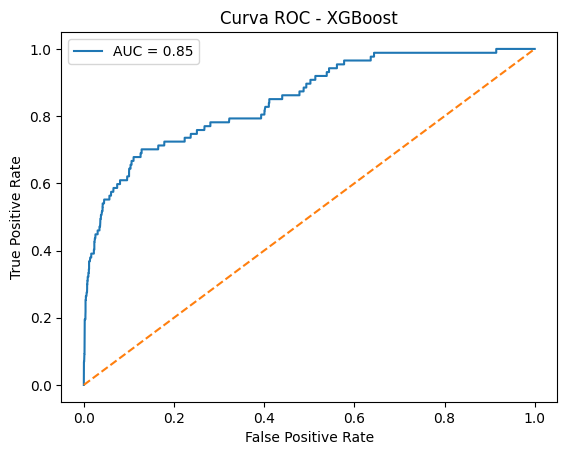

In [139]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.2f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - XGBoost")
plt.legend()
plt.show()